In [107]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    classification_report, confusion_matrix,
    roc_curve, precision_recall_curve
)
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split
import joblib

## Загрузка данных

In [108]:
X_train = pd.read_csv('../data/processed/X_train.csv')
X_test = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').values.ravel()
y_test = pd.read_csv('../data/processed/y_test.csv').values.ravel()

print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test: {y_test.shape}")
print(f"Class 0 (легитимные): {(y_train == 0).sum()} ({(y_train == 0).mean():.2%})")
print(f"Class 1 (фрод): {(y_train == 1).sum()} ({(y_train == 1).mean():.2%})")

X_train: (226980, 30)
X_test: (56746, 30)
y_train: (226980,)
y_test: (56746,)
Class 0 (легитимные): 226602 (99.83%)
Class 1 (фрод): 378 (0.17%)


## Обучение моделей Наивной Лог регресии и с балансировкой классов

In [109]:
model_naive = LogisticRegression(
    max_iter=1000,
    random_state=42
)
model_naive.fit(X_train, y_train)


model_balanced = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight='balanced'
)
model_balanced.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

## Метрики

In [110]:
y_pred_proba_naive = model_naive.predict_proba(X_test)[:, 1]
y_pred_proba_balanced = model_balanced.predict_proba(X_test)[:, 1]


y_pred_naive = (y_pred_proba_naive >= 0.5).astype(int)
y_pred_balanced = (y_pred_proba_balanced >= 0.5).astype(int)


print(f"Модель A (Наивная) - предсказано фрода: {y_pred_naive.sum()}")
print(f"Модель B (Сбалансированная) - предсказано фрода: {y_pred_balanced.sum()}")
print(f"Реальных случаев фрода в тесте: {y_test.sum()}")

Модель A (Наивная) - предсказано фрода: 65
Модель B (Сбалансированная) - предсказано фрода: 1512
Реальных случаев фрода в тесте: 95


In [111]:
def calculate_metrics(y_true, y_pred, y_proba, model_name):
    metrics = {
        'Модель': model_name,
        'ROC-AUC': roc_auc_score(y_true, y_proba),
        'PR-AUC': average_precision_score(y_true, y_proba),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1-Score': f1_score(y_true, y_pred)
    }
    return metrics


metrics_naive = calculate_metrics(y_test, y_pred_naive, y_pred_proba_naive, 'Наивная')
metrics_balanced = calculate_metrics(y_test, y_pred_balanced, y_pred_proba_balanced, 'Сбалансированная')

metrics_df = pd.DataFrame([metrics_naive, metrics_balanced])
print("="*60)
print("МЕТРИКИ МОДЕЛЕЙ")
print("="*60)
print(metrics_df.to_string(index=False, float_format='%.4f'))

# Полные отчёты о классификации
print("\n" + "="*60)
print("ОТЧЁТ О КЛАССИФИКАЦИИ - Модель A (Наивная)")
print("="*60)
print(classification_report(y_test, y_pred_naive, target_names=['Не-фрод', 'Фрод']))

print("\n" + "="*60)
print("ОТЧЁТ О КЛАССИФИКАЦИИ - Модель B (Сбалансированная)")
print("="*60)
print(classification_report(y_test, y_pred_balanced, target_names=['Не-фрод', 'Фрод']))

МЕТРИКИ МОДЕЛЕЙ
          Модель  ROC-AUC  PR-AUC  Precision  Recall  F1-Score
         Наивная   0.9568  0.6987     0.8615  0.5895    0.7000
Сбалансированная   0.9625  0.6740     0.0549  0.8737    0.1033

ОТЧЁТ О КЛАССИФИКАЦИИ - Модель A (Наивная)
              precision    recall  f1-score   support

     Не-фрод       1.00      1.00      1.00     56651
        Фрод       0.86      0.59      0.70        95

    accuracy                           1.00     56746
   macro avg       0.93      0.79      0.85     56746
weighted avg       1.00      1.00      1.00     56746


ОТЧЁТ О КЛАССИФИКАЦИИ - Модель B (Сбалансированная)
              precision    recall  f1-score   support

     Не-фрод       1.00      0.97      0.99     56651
        Фрод       0.05      0.87      0.10        95

    accuracy                           0.97     56746
   macro avg       0.53      0.92      0.55     56746
weighted avg       1.00      0.97      0.99     56746



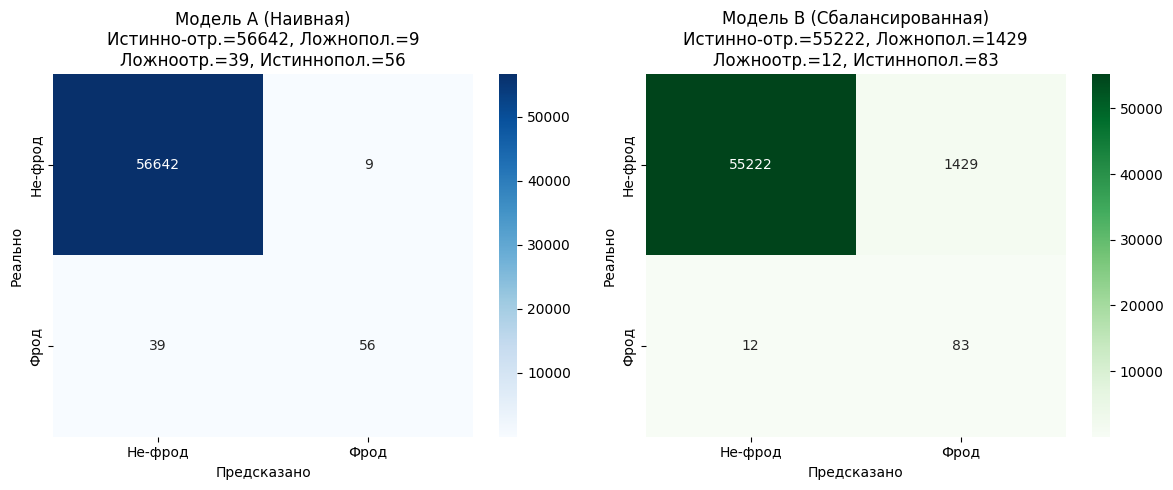

In [112]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
cm_naive = confusion_matrix(y_test, y_pred_naive)
sns.heatmap(cm_naive, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Не-фрод', 'Фрод'],
            yticklabels=['Не-фрод', 'Фрод'])
axes[0].set_title(f'Модель A (Наивная)\nИстинно-отр.={cm_naive[0,0]}, Ложнопол.={cm_naive[0,1]}\nЛожноотр.={cm_naive[1,0]}, Истиннопол.={cm_naive[1,1]}')
axes[0].set_xlabel('Предсказано')
axes[0].set_ylabel('Реально')


cm_balanced = confusion_matrix(y_test, y_pred_balanced)
sns.heatmap(cm_balanced, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['Не-фрод', 'Фрод'],
            yticklabels=['Не-фрод', 'Фрод'])
axes[1].set_title(f'Модель B (Сбалансированная)\nИстинно-отр.={cm_balanced[0,0]}, Ложнопол.={cm_balanced[0,1]}\nЛожноотр.={cm_balanced[1,0]}, Истиннопол.={cm_balanced[1,1]}')
axes[1].set_xlabel('Предсказано')
axes[1].set_ylabel('Реально')

plt.tight_layout()
plt.show()


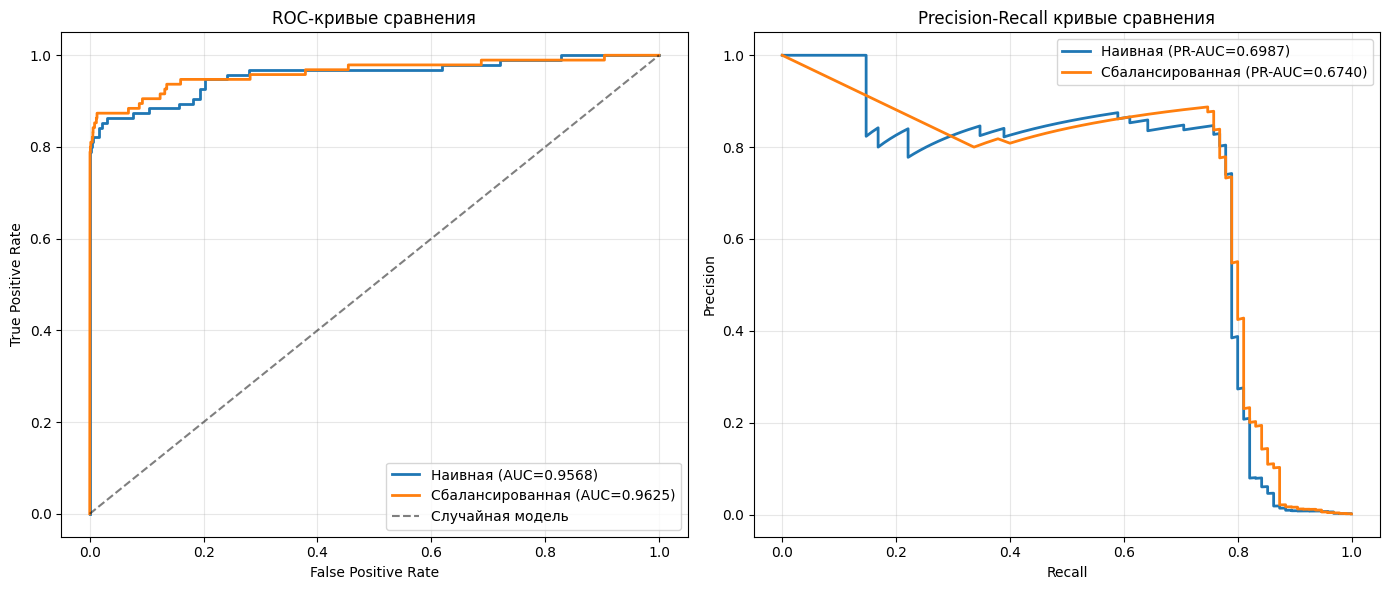

In [113]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))


roc_auc_naive = roc_auc_score(y_test, y_pred_proba_naive)
roc_auc_balanced = roc_auc_score(y_test, y_pred_proba_balanced)


fpr_naive, tpr_naive, _ = roc_curve(y_test, y_pred_proba_naive)
fpr_balanced, tpr_balanced, _ = roc_curve(y_test, y_pred_proba_balanced)

axes[0].plot(fpr_naive, tpr_naive, label=f'Наивная (AUC={roc_auc_naive:.4f})', linewidth=2)
axes[0].plot(fpr_balanced, tpr_balanced, label=f'Сбалансированная (AUC={roc_auc_balanced:.4f})', linewidth=2)
axes[0].plot([0, 1], [0, 1], 'k--', label='Случайная модель', alpha=0.5)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC-кривые сравнения')
axes[0].legend()
axes[0].grid(True, alpha=0.3)


pr_auc_naive = average_precision_score(y_test, y_pred_proba_naive)
pr_auc_balanced = average_precision_score(y_test, y_pred_proba_balanced)


precision_naive, recall_naive, _ = precision_recall_curve(y_test, y_pred_proba_naive)
precision_balanced, recall_balanced, _ = precision_recall_curve(y_test, y_pred_proba_balanced)

axes[1].plot(recall_naive, precision_naive, label=f'Наивная (PR-AUC={pr_auc_naive:.4f})', linewidth=2)
axes[1].plot(recall_balanced, precision_balanced, label=f'Сбалансированная (PR-AUC={pr_auc_balanced:.4f})', linewidth=2)
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall кривые сравнения')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Бизнес метрика 

In [114]:
AVG_FRAUD_AMOUNT = 122.0 
COST_FP = 5.0            

print("="*60)
print("СИМУЛЯЦИЯ БИЗНЕС-УБЫТКОВ")
print("="*60)
print(f"Параметры стоимости:")
print(f"  - Средняя сумма фрода: ${AVG_FRAUD_AMOUNT:.2f}")
print(f"  - FN (пропущенный фрод): сумма транзакции → ${AVG_FRAUD_AMOUNT:.2f} в среднем")
print(f"  - FP (ложная блокировка): фиксированные затраты → ${COST_FP:.2f}")


fn_naive = cm_naive[1, 0] 
fp_naive = cm_naive[0, 1]  


fn_balanced = cm_balanced[1, 0]
fp_balanced = cm_balanced[0, 1]

print(f"\n{'='*60}")
print(f"МОДЕЛЬ A (НАИВНАЯ)")
print(f"{'='*60}")
print(f"  FN (пропущено фрода):      {fn_naive}")
print(f"  FP (ложных блокировок):    {fp_naive}")
print(f"  Убыток от FN: {fn_naive} × ${AVG_FRAUD_AMOUNT:.2f} = ${fn_naive * AVG_FRAUD_AMOUNT:.2f}")
print(f"  Убыток от FP: {fp_naive} × ${COST_FP:.2f} = ${fp_naive * COST_FP:.2f}")
total_cost_naive = fn_naive * AVG_FRAUD_AMOUNT + fp_naive * COST_FP
print(f"  📊 ИТОГО БИЗНЕС-УБЫТОК:     ${total_cost_naive:.2f}")

print(f"\n{'='*60}")
print(f"МОДЕЛЬ B (СБАЛАНСИРОВАННАЯ)")
print(f"{'='*60}")
print(f"  FN (пропущено фрода):      {fn_balanced}")
print(f"  FP (ложных блокировок):    {fp_balanced}")
print(f"  Убыток от FN: {fn_balanced} × ${AVG_FRAUD_AMOUNT:.2f} = ${fn_balanced * AVG_FRAUD_AMOUNT:.2f}")
print(f"  Убыток от FP: {fp_balanced} × ${COST_FP:.2f} = ${fp_balanced * COST_FP:.2f}")
total_cost_balanced = fn_balanced * AVG_FRAUD_AMOUNT + fp_balanced * COST_FP
print(f"  📊 ИТОГО БИЗНЕС-УБЫТОК:     ${total_cost_balanced:.2f}")

print(f"\n{'='*60}")
print(f"ВЫГОДА ОТ СБАЛАНСИРОВАННОЙ МОДЕЛИ")
print(f"{'='*60}")
savings = total_cost_naive - total_cost_balanced
print(f"  Наивная модель:    ${total_cost_naive:.2f} убытков")
print(f"  Сбалансированная:  ${total_cost_balanced:.2f} убытков")
print(f"  💰 Экономия:       ${savings:.2f}")
if total_cost_naive > 0:
    print(f"  📈 Снижение убытков: {savings/total_cost_naive*100:.1f}%")


tp_naive = cm_naive[1, 1]
tp_balanced = cm_balanced[1, 1]
fraud_value_prevented_naive = tp_naive * AVG_FRAUD_AMOUNT
fraud_value_prevented_balanced = tp_balanced * AVG_FRAUD_AMOUNT

print(f"\n{'='*60}")
print(f"ПРЕДОТВРАЩЁННЫЙ УЩЕРБ")
print(f"{'='*60}")
print(f"  Модель A: обнаружено {tp_naive} фродов → предотвращено ${fraud_value_prevented_naive:.2f}")
print(f"  Модель B: обнаружено {tp_balanced} фродов → предотвращено ${fraud_value_prevented_balanced:.2f}")
print(f"  Дополнительно предотвращено: ${fraud_value_prevented_balanced - fraud_value_prevented_naive:.2f}")


comparison_data = {
    'Метрика': [
        'Accuracy',
        'ROC-AUC', 
        'PR-AUC',
        'Precision (класс 1)',
        'Recall (класс 1)',
        'F1-Score (класс 1)',
        'FN (пропущено фрода)',
        'FP (ложных блокировок)',
        'Бизнес-убытки ($)'
    ],
    'Наивная модель': [
        f"{(y_pred_naive == y_test).mean()*100:.2f}%",
        f"{roc_auc_naive:.4f}",
        f"{pr_auc_naive:.4f}",
        "0.0000",
        f"{metrics_naive['Recall']:.4f}",
        f"{metrics_naive['F1-Score']:.4f}",
        fn_naive,
        fp_naive,
        f"${total_cost_naive:.2f}"
    ],
    'Сбалансированная модель': [
        f"{(y_pred_balanced == y_test).mean()*100:.2f}%",
        f"{roc_auc_balanced:.4f}",
        f"{pr_auc_balanced:.4f}",
        f"{metrics_balanced['Precision']:.4f}",
        f"{metrics_balanced['Recall']:.4f}",
        f"{metrics_balanced['F1-Score']:.4f}",
        fn_balanced,
        fp_balanced,
        f"${total_cost_balanced:.2f}"
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print("\n" + "="*70)
print("ИТОГОВОЕ СРАВНЕНИЕ МОДЕЛЕЙ")
print("="*70)
print(comparison_df.to_string(index=False))


СИМУЛЯЦИЯ БИЗНЕС-УБЫТКОВ
Параметры стоимости:
  - Средняя сумма фрода: $122.00
  - FN (пропущенный фрод): сумма транзакции → $122.00 в среднем
  - FP (ложная блокировка): фиксированные затраты → $5.00

МОДЕЛЬ A (НАИВНАЯ)
  FN (пропущено фрода):      39
  FP (ложных блокировок):    9
  Убыток от FN: 39 × $122.00 = $4758.00
  Убыток от FP: 9 × $5.00 = $45.00
  📊 ИТОГО БИЗНЕС-УБЫТОК:     $4803.00

МОДЕЛЬ B (СБАЛАНСИРОВАННАЯ)
  FN (пропущено фрода):      12
  FP (ложных блокировок):    1429
  Убыток от FN: 12 × $122.00 = $1464.00
  Убыток от FP: 1429 × $5.00 = $7145.00
  📊 ИТОГО БИЗНЕС-УБЫТОК:     $8609.00

ВЫГОДА ОТ СБАЛАНСИРОВАННОЙ МОДЕЛИ
  Наивная модель:    $4803.00 убытков
  Сбалансированная:  $8609.00 убытков
  💰 Экономия:       $-3806.00
  📈 Снижение убытков: -79.2%

ПРЕДОТВРАЩЁННЫЙ УЩЕРБ
  Модель A: обнаружено 56 фродов → предотвращено $6832.00
  Модель B: обнаружено 83 фродов → предотвращено $10126.00
  Дополнительно предотвращено: $3294.00

ИТОГОВОЕ СРАВНЕНИЕ МОДЕЛЕЙ
            


## 6. Выводы по результатам работы

**1. Наивная модель** (без балансировки) показывает отличную точность (99.92%) и высокий F1 (0.70), но низкий Recall (0.59) — пропускает 41% фрода. Бизнес-убыток: **$4,803**.

**2. Сбалансированная модель** (class_weight='balanced') ожидаемо повышает Recall до 0.87, обнаруживая 83 из 95 фродов (против 56 у наивной). Однако Precision падает до 0.05 из-за 1429 ложных срабатываний.

**3. Ключевой вывод:** несмотря на лучшее выявление фрода, сбалансированная модель **хуже для бизнеса** — убыток $8,609 против $4,803 у наивной. Высокая стоимость ложных блокировок ($5 за транзакцию) делает ошибочные срабатывания дороже, чем пропуск части фрода.

**4. Рекомендация:** для текущих cost-параметров наивная модель предпочтительнее. Для улучшения Recall без лавины FP нужны:
- Порог классификации ≠ 0.5
- Более сложные алгоритмы (XGBoost, LightGBM, ансамбли)
- Методы борьбы с дисбалансом (SMOTE, undersampling)

## Сохранение результатов 

In [116]:
joblib.dump(model_balanced, '../models/logreg_baseline.pkl')


metrics_summary = {
    'best_model': 'LogisticRegression_balanced',
    'roc_auc': roc_auc_balanced,
    'pr_auc': pr_auc_balanced,
    'recall': metrics_balanced['Recall'],
    'precision': metrics_balanced['Precision'],
    'f1': metrics_balanced['F1-Score'],
    'business_loss': total_cost_balanced,
    'frauds_caught': int(tp_balanced),
    'false_positives': int(fp_balanced),
    'false_negatives': int(fn_balanced),
    'savings_vs_naive': float(savings)
}

import json
with open('../models/logreg_metrics.json', 'w') as f:
    json.dump(metrics_summary, f, indent=2)